In [1]:
import os
print(os.getcwd())

/media/drive/daniela/Projects/clf_Financial_transacction/notebooks


In [15]:
!pip install scikit-learn -q

## Imports

In [2]:
import pandas as pd 
import numpy as np
from collections import Counter
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from sklearn.base import TransformerMixin
import nltk
from nltk.corpus import stopwords
import re



In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/umy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
# Set seed for reproducibility
np.random.seed(42)

## Data Exploring and cleaning

In [5]:
pwd

'/media/drive/daniela/Projects/clf_Financial_transacction/notebooks'

In [6]:
raw_data_train = pd.read_csv('../data/raw/train_transactions.csv', sep=",")

In [7]:
raw_data_train.head()

,transaction_text,category
0,Uber ride INR 48648 TXNde8842f7,travel
1,Flipkart order INR 14678 TXN17584829,shopping
2,Home loan EMI INR 44398 TXN8962c016,emi
3,Netflix subscription INR 38748 TXNdce4ee96,entertainment
4,Hospital bill INR 2002 TXNb7e25951,healthcare


In [8]:
raw_data_train.shape

(5000, 2)

In [9]:
raw_data_train["category"].nunique()

9

In [10]:
raw_data_train["category"].unique()


array(['travel', 'shopping', 'emi', 'entertainment', 'healthcare',
       'investment', 'utilities', 'food', 'education'], dtype=object)

In [11]:
raw_data_train["category"].value_counts()

category
education        602
healthcare       570
travel           565
entertainment    557
utilities        554
shopping         546
emi              541
food             534
investment       531
Name: count, dtype: int64

In [12]:
raw_data_train.isnull().sum()

transaction_text    0
category            0
dtype: int64

In [13]:
raw_data_train['transaction_text'].duplicated().sum()

np.int64(0)

In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
raw_data_train['category_encoded'] = le.fit_transform(raw_data_train['category'])

# Show the mapping
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:")
for cat, code in sorted(label_mapping.items(), key=lambda x: x[1]):
    print(f"  {code} -> {cat}")

print()
raw_data_train[['category', 'category_encoded']].head(10)

Label mapping:
  0 -> education
  1 -> emi
  2 -> entertainment
  3 -> food
  4 -> healthcare
  5 -> investment
  6 -> shopping
  7 -> travel
  8 -> utilities



,category,category_encoded
0,travel,7
1,shopping,6
2,emi,1
3,entertainment,2
4,healthcare,4
5,travel,7
6,entertainment,2
7,investment,5
8,investment,5
9,shopping,6


In [15]:
raw_data_train['category_encoded'].value_counts()

category_encoded
0    602
4    570
7    565
2    557
8    554
6    546
1    541
3    534
5    531
Name: count, dtype: int64

#### Category distribution

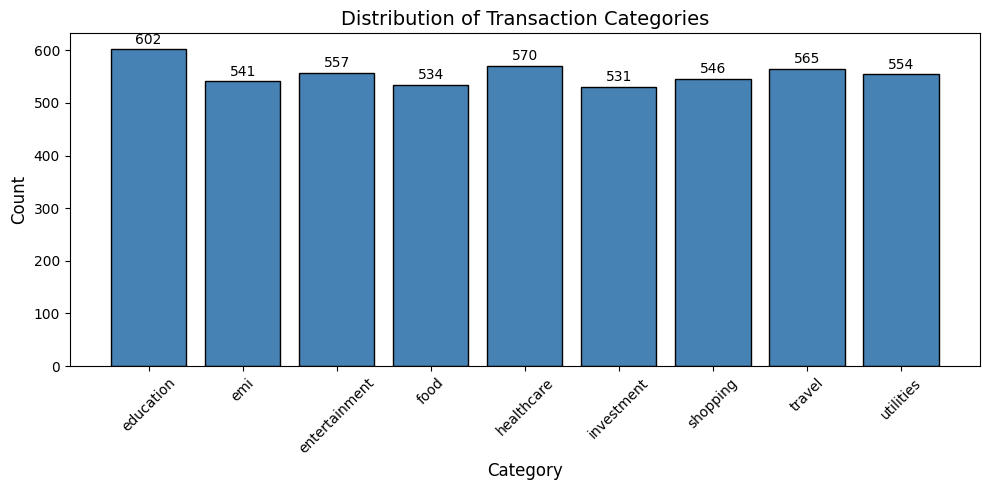

In [16]:

fig, ax = plt.subplots(figsize=(10, 5))

counts = raw_data_train['category'].value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color='steelblue', edgecolor='black')

ax.set_title('Distribution of Transaction Categories', fontsize=14)
ax.set_xlabel('Category', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.tick_params(axis='x', rotation=45)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [22]:
## length of transaction text
lengths = raw_data_train['transaction_text'].apply(len)
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [23]:
print("mean length:", lengths.mean())
print("median length:", lengths.median())
print("max length:", lengths.max())
print("min length:", lengths.min())

mean length: 38.2366
median length: 37.0
max length: 48
min length: 27


## Data splitting

### Data split

In [17]:
X = raw_data_train.drop(columns=['category', 'category_encoded'])
y = raw_data_train['category_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


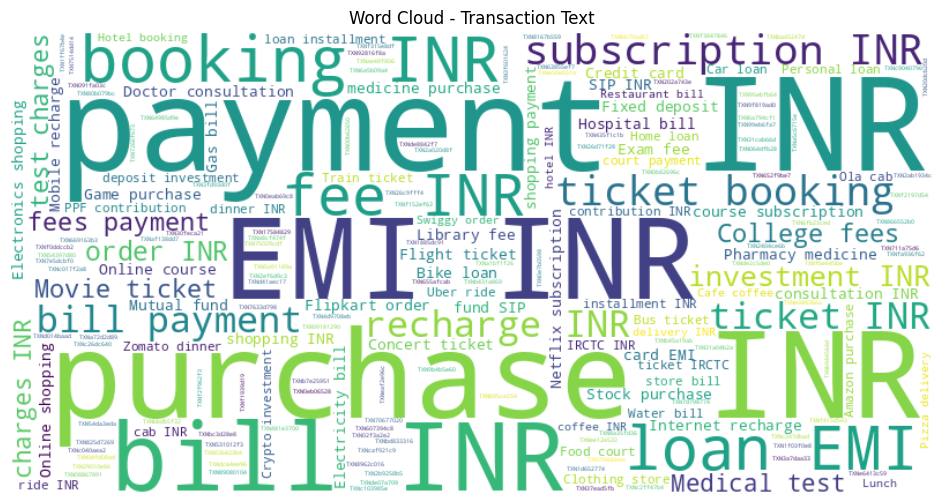

In [18]:
## Word Cloud for Transaction Text

text = ' '.join(raw_data_train['transaction_text'])
wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud - Transaction Text')
plt.show()

In [19]:
raw_data_train.head()

,transaction_text,category,category_encoded
0,Uber ride INR 48648 TXNde8842f7,travel,7
1,Flipkart order INR 14678 TXN17584829,shopping,6
2,Home loan EMI INR 44398 TXN8962c016,emi,1
3,Netflix subscription INR 38748 TXNdce4ee96,entertainment,2
4,Hospital bill INR 2002 TXNb7e25951,healthcare,4


In [20]:
for i in range(20):
    print(f"Transaction {i+1}: {raw_data_train['transaction_text'][i]}")

Transaction 1: Uber ride INR 48648 TXNde8842f7
Transaction 2: Flipkart order INR 14678 TXN17584829
Transaction 3: Home loan EMI INR 44398 TXN8962c016
Transaction 4: Netflix subscription INR 38748 TXNdce4ee96
Transaction 5: Hospital bill INR 2002 TXNb7e25951
Transaction 6: Ola cab INR 15297 TXN7d798774
Transaction 7: Netflix subscription INR 36831 TXN669163b3
Transaction 8: Crypto investment INR 27543 TXN08867891
Transaction 9: PPF contribution INR 38668 TXN3a7daa33
Transaction 10: Amazon purchase INR 49779 TXN8a35fd36
Transaction 11: Credit card EMI INR 22348 TXNde07a709
Transaction 12: Flipkart order INR 14160 TXNae48f806
Transaction 13: Electricity bill payment INR 6128 TXN3fd93d0f
Transaction 14: Hospital bill INR 23576 TXNc040aea2
Transaction 15: Mobile recharge INR 17385 TXN9f819ad0
Transaction 16: Pizza delivery INR 30158 TXN7046bb4e
Transaction 17: Netflix subscription INR 24857 TXN711a75d6
Transaction 18: Hotel booking INR 19263 TXNbad3247d
Transaction 19: Mobile recharge INR 1

### Data preprocessing

In [21]:
# preprocessing 
class TextPreprocessor(TransformerMixin):
    def __init__(self):
        self.stop_words = set(stopwords.words('english'))  
    
    def _process_text(self, text):
        text = text.lower()
        # Replace TXN codes with placeholder
        text = re.sub(r"txn[a-z0-9]+", "TXN_CODE", text)
        # Replace currency codes with placeholder
        text = re.sub(r"\b(?:inr|usd|eur|gbp|jpy|cny)\b", "CURRENCY", text)
        # Replace numbers with placeholder
        text = re.sub(r"\b\d+\b", "AMOUNT", text)
        # Remove stopwords
        tokens = text.split()
        tokens = [word for word in tokens if word not in self.stop_words]
        return ' '.join(tokens)
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X.apply(self._process_text)


### Preprocessing data Pipeline

NameError: name 'raw_data_train' is not defined

In [ ]:
# Apply text preprocessing
preprocessor = TextPreprocessor()
X_train_clean = preprocessor.transform(X_train['transaction_text'])
X_test_clean = preprocessor.transform(X_test['transaction_text'])

print("Before preprocessing:")
print(X_train['transaction_text'].iloc[0])
print("\nAfter preprocessing:")
print(X_train_clean.iloc[0])

In [ ]:
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=500)
X_train_tfidf = tfidf.fit_transform(X_train_clean)
X_test_tfidf = tfidf.transform(X_test_clean)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test):  {X_test_tfidf.shape}")
print(f"\nTop 20 features: {tfidf.get_feature_names_out()[:20]}")